# Singapore Tourism Arrivals — Week 4: Backtesting Framework

**Goal:** Stress-test all four models across multiple historical decision points — not just one held-out window  
**New concepts:** Expanding-window backtesting · Rolling conformal calibration · Diebold-Mariano significance test  
**Deliverable:** A consulting-grade model comparison table that is honest about every metric  

---

## Data Decisions Log (Week 4)

| Decision | Rationale |
|---|---|
| Expanding window (not sliding) | Tourism arrivals have long-range trends; discarding old data removes signal more than it removes stale structure |
| Minimum training length: 5 years | Models with fewer than 60 monthly observations produce unreliable seasonal estimates (especially SARIMA's seasonal AR/MA terms) |
| Backtest origin: 2010-01 | Gives 9 rolling windows before the 2019 validation wall; avoids the sparse data years of the early 2000s |
| Rolling conformal calibration: trailing 24 months | Fixed-window conformal (W3 style) can only be applied once; rolling calibration re-estimates q̂ at every backtest origin using the most recent 24 residuals |
| Test set unlocked this week | ≥ 2022 is genuinely held out until now — do not touch it until Section 6 |
| MAPE added to MAE/RMSE | Percentage error lets you compare across countries without worrying about absolute arrival scale |
| Diebold-Mariano at 5% level | Tests whether SARIMA's lower MAE vs ARIMA is statistically distinguishable or just luck |
| NeuralProphet excluded from DM test | Stochastic training means prediction errors are not reproducible across windows — violates the DM stationarity assumption |


---

## 0. Setup & Dependencies

In [ ]:
# Install Week 4 dependencies (run once — same stack as W1–W3 plus scipy for DM test)
# !pip install pmdarima prophet neuralprophet pandas numpy matplotlib seaborn scikit-learn scipy

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from itertools import product as iterproduct

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats

import pmdarima as pm

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet import Prophet

from neuralprophet import NeuralProphet

# ── Consistent aesthetics across all weeks ────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Colour palette (same as prior weeks) ─────────────────────────────────
PALETTE = {
    'ARIMA':         '#2c7bb6',
    'SARIMA':        '#4575b4',
    'Prophet':       '#d7191c',
    'NeuralProphet': '#1a9641',
}

DATA_DIR = Path('data')
SEED     = 42
ALPHA    = 0.05          # target miscoverage — 95% intervals
K_CAL    = 24            # rolling conformal calibration window (months)

print('Libraries loaded ✓')

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


Libraries loaded ✓


---

## 1. Load Data & Define Backtest Grid

The backtest grid is defined by a sequence of **forecast origins** — dates at which we
pretend we are making a real-time prediction.  At each origin:

1. All data **before** the origin is available for training.
2. The **12 months after** the origin form the forecast horizon.
3. We re-fit each model from scratch, re-calibrate conformal intervals, and score against actuals.

```
Origin         Training data used          Forecast window
─────────────────────────────────────────────────────────
2010-01-01     ≤ 2009-12                   2010-01 → 2010-12
2011-01-01     ≤ 2010-12                   2011-01 → 2011-12
  ...               ...                         ...
2018-01-01     ≤ 2017-12                   2018-01 → 2018-12
──────────────────────────── validation wall ────────────────
TEST (2022+)   ≤ 2021-12                   2022-01 → 2022-12   [unlocked in §6]
```

> **Why stop at 2018?** 2019 was used as the dedicated validation window in W1–W3.
> We do not include 2019 or any COVID year (2020–2021) in the backtest to avoid
> the models seeing structural breaks they were never designed to handle.

In [3]:
clean_path = DATA_DIR / 'arrivals_clean.csv'
assert clean_path.exists(), "Run the Week 1 notebook first to generate arrivals_clean.csv"

df = pd.read_csv(clean_path, parse_dates=['date'])

# Same focus country as W1–W3
FOCUS_COUNTRY = (
    df[df['date'] < '2020-01-01']
    .groupby('country')['arrivals']
    .sum()
    .idxmax()
)
print(f"Focus country: {FOCUS_COUNTRY}")

ts = (
    df[df['country'] == FOCUS_COUNTRY]
    .sort_values('date')
    .reset_index(drop=True)
    .copy()
)
ts['log_arrivals'] = np.log1p(ts['arrivals'])

# ── Backtest origins: Jan of each year 2010 → 2018 ───────────────────────
BACKTEST_ORIGINS = pd.date_range('2010-01-01', '2018-01-01', freq='YS')
MIN_TRAIN_MONTHS = 60    # 5 years minimum
HORIZON          = 12    # predict 12 months ahead at each origin

# Pre-compute the locked test set (≥ 2022) — DO NOT inspect until §6
ts_test = ts[ts['date'] >= '2022-01-01'].copy()

print(f"\nFull series : {ts['date'].min().date()} → {ts['date'].max().date()}  ({len(ts)} months)")
print(f"Backtest origins : {len(BACKTEST_ORIGINS)} windows  ({BACKTEST_ORIGINS[0].date()} → {BACKTEST_ORIGINS[-1].date()})")
print(f"Forecast horizon : {HORIZON} months per origin")
print(f"Test set   : {ts_test['date'].min().date()} → {ts_test['date'].max().date()}  ({len(ts_test)} months) [LOCKED until §6]")

Focus country: Greater China

Full series : 2008-01-01 → 2026-01-01  (217 months)
Backtest origins : 9 windows  (2010-01-01 → 2018-01-01)
Forecast horizon : 12 months per origin
Test set   : 2022-01-01 → 2026-01-01  (49 months) [LOCKED until §6]


---

## 2. Helper Functions

All the machinery from W2–W3 is consolidated here into clean, reusable functions.
The key addition is `rolling_conformal_interval`, which re-calibrates q̂ at every
origin using the trailing 24 residuals instead of a fixed held-out set.

In [4]:
# ── Metric helpers ────────────────────────────────────────────────────────

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — skip zeros to avoid division error."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_metrics(y_true, y_pred, lower=None, upper=None):
    """Return dict of MAE, RMSE, MAPE, and (optionally) coverage + avg_width."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    out = {
        'mae' : mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mape(y_true, y_pred),
    }
    if lower is not None and upper is not None:
        lower, upper = np.asarray(lower), np.asarray(upper)
        inside       = (y_true >= lower) & (y_true <= upper)
        out['coverage']  = inside.mean()
        out['avg_width'] = (upper - lower).mean()
    return out


# ── Rolling conformal calibration ─────────────────────────────────────────

def rolling_conformal_q(cal_residuals_log, alpha=0.05):
    """
    Compute the conformal quantile q̂ from a 1-D array of absolute log residuals.
    Uses the finite-sample correction: ceil((n+1)(1-α)/n) instead of plain (1-α).
    Returns q̂ in LOG space (same as W3 convention).
    """
    n   = len(cal_residuals_log)
    lvl = np.ceil((n + 1) * (1 - alpha)) / n
    lvl = min(lvl, 1.0)                    # cap at 1 for very small n
    return float(np.quantile(cal_residuals_log, lvl))


def conformal_interval_from_q(pred_log, q_hat):
    """Apply q̂ in log space, return (lower_orig, upper_orig) in original scale."""
    pred_log = np.asarray(pred_log)
    lower    = np.expm1(pred_log - q_hat)
    upper    = np.expm1(pred_log + q_hat)
    return lower, upper


# ── Prophet helper ────────────────────────────────────────────────────────

def to_prophet_df(subset, log_col='log_arrivals'):
    return subset[['date', log_col]].rename(columns={'date': 'ds', log_col: 'y'})


print('Helper functions defined ✓')

Helper functions defined ✓


---

## 3. Diebold-Mariano Test (function)

The DM test asks: **are two models' forecast errors distinguishably different,
or could the gap be explained by sampling variability alone?**

We use the two-sided variant with a modified Harvey-Leybourne-Newbold (HLN) correction
for finite samples.  The null hypothesis is equal predictive accuracy.

```
d_t = L(e1_t) − L(e2_t)        where L is squared loss
DM  = d̄ / sqrt( V̂(d̄) )       asymptotically N(0,1)
HLN = DM · sqrt( (T+1−2h+T⁻¹h(h−1)) / T )   finite-sample correction
```

Reference: Diebold & Mariano (1995); Harvey, Leybourne & Newbold (1997).

In [5]:
def diebold_mariano_test(e1, e2, h=1, loss='squared'):
    """
    Diebold-Mariano test with Harvey-Leybourne-Newbold finite-sample correction.

    Parameters
    ----------
    e1, e2 : array-like  — forecast errors from model 1 and model 2
    h      : int         — forecast horizon (1 for 1-step-ahead)
    loss   : str         — 'squared' (MSE-based) or 'absolute' (MAE-based)

    Returns
    -------
    dict with 'dm_stat', 'p_value', 'verdict' (str)
    """
    e1, e2 = np.asarray(e1, dtype=float), np.asarray(e2, dtype=float)
    T      = len(e1)
    assert len(e2) == T, "Error arrays must have equal length"

    # Loss differential
    if loss == 'squared':
        d = e1 ** 2 - e2 ** 2
    else:
        d = np.abs(e1) - np.abs(e2)

    d_bar = np.mean(d)

    # Newey-West long-run variance (bandwidth = h-1)
    gamma0 = np.var(d, ddof=1)
    gamma  = gamma0
    for k in range(1, h):
        cov_k  = np.cov(d[k:], d[:-k])[0, 1]
        gamma += 2 * (1 - k / h) * cov_k
    gamma  = max(gamma, 1e-12)    # avoid division by zero on constant series

    # Raw DM statistic
    dm = d_bar / np.sqrt(gamma / T)

    # HLN finite-sample correction factor
    hln_factor = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_hln     = dm * hln_factor

    # t-distribution with T-1 degrees of freedom (HLN recommendation)
    p_value = 2 * stats.t.sf(np.abs(dm_hln), df=T - 1)

    if p_value < 0.01:
        verdict = 'Significant (p<0.01)'
    elif p_value < 0.05:
        verdict = 'Significant (p<0.05)'
    elif p_value < 0.10:
        verdict = 'Marginal (p<0.10)'
    else:
        verdict = 'Not significant'

    return {'dm_stat': round(dm_hln, 3), 'p_value': round(p_value, 4), 'verdict': verdict}


print('Diebold-Mariano function defined ✓')

Diebold-Mariano function defined ✓


---

## 4. Rolling Backtest Loop

At each origin we:

1. Slice `train_bt` = all data strictly before the origin date
2. Slice `cal_bt`   = trailing `K_CAL` months of `train_bt` (for rolling conformal)
3. Fit each model on `train_bt`
4. Compute HORIZON-step predictions + conformal intervals
5. Score against actual arrivals
6. Append to `backtest_records`

> **NeuralProphet note:** NeuralProphet's stochastic training makes it ~10× slower
> per window than the other models.  We reduce epochs to 50 for the backtest.
> If you are on CPU, expect ~4 minutes per origin (≈35 min total).  Set
> `RUN_NP = False` to skip it and still get full results for the other three.

In [8]:
RUN_NP = False   # set False to skip NeuralProphet and save ~35 min on CPU

backtest_records = []   # one row per (origin, model, horizon_step)

for origin in BACKTEST_ORIGINS:

    # ── Data slices ───────────────────────────────────────────────────────
    train_bt = ts[ts['date'] < origin].copy()
    fcast_bt = ts[(ts['date'] >= origin) &
                  (ts['date'] < origin + pd.DateOffset(months=HORIZON))].copy()

    if len(train_bt) < MIN_TRAIN_MONTHS or len(fcast_bt) < HORIZON:
        print(f"  [SKIP] {origin.date()} — insufficient data")
        continue

    # Rolling calibration window = trailing K_CAL months of training
    cal_bt = train_bt.tail(K_CAL).copy()
    pre_cal_bt = train_bt.iloc[:-K_CAL].copy()   # all training BEFORE cal window

    actuals_orig = np.expm1(fcast_bt['log_arrivals'].values)
    actuals_log  = fcast_bt['log_arrivals'].values

    print(f"\n═══ Origin: {origin.date()}  |  train={len(train_bt)}mo  cal={len(cal_bt)}mo  "
          f"horizon={len(fcast_bt)}mo ═══")

    # ═══════════════════════════════════════════════════════════════════════
    # 4a. ARIMA
    # ═══════════════════════════════════════════════════════════════════════
    arima_bt = pm.auto_arima(
        train_bt['log_arrivals'],
        seasonal=False,
        information_criterion='aic',
        max_p=5, max_q=5, max_d=2,
        stepwise=True,
        suppress_warnings=True,
        random_state=SEED,
    )
    arima_preds_log, _ = arima_bt.predict(n_periods=HORIZON, return_conf_int=True)

    # Re-calibrate conformal on trailing K_CAL residuals
    cal_preds_arima, _ = arima_bt.predict(
        n_periods=K_CAL,          # predict backward from end of pre-cal
        return_conf_int=True
    )
    # Fit a fresh model on pre_cal to get calibration residuals
    arima_precal = pm.auto_arima(
        pre_cal_bt['log_arrivals'],
        seasonal=False,
        information_criterion='aic',
        max_p=5, max_q=5, max_d=2,
        stepwise=True,
        suppress_warnings=True,
        random_state=SEED,
    )
    arima_cal_preds, _ = arima_precal.predict(n_periods=K_CAL, return_conf_int=True)
    arima_cal_scores   = np.abs(cal_bt['log_arrivals'].values - arima_cal_preds)
    arima_q_hat        = rolling_conformal_q(arima_cal_scores, ALPHA)
    arima_cp_lo, arima_cp_hi = conformal_interval_from_q(arima_preds_log, arima_q_hat)

    arima_m = compute_metrics(
        actuals_orig, np.expm1(arima_preds_log),
        arima_cp_lo, arima_cp_hi
    )
    arima_m.update({'origin': origin, 'model': 'ARIMA',
                    'errors': (actuals_orig - np.expm1(arima_preds_log)).tolist(),
                    'q_hat': arima_q_hat})
    backtest_records.append(arima_m)
    print(f"  ARIMA   MAE={arima_m['mae']:>9,.0f}  RMSE={arima_m['rmse']:>9,.0f}  "
          f"MAPE={arima_m['mape']:5.1f}%  Cov={arima_m['coverage']:.0%}  "
          f"q̂={arima_q_hat:.3f}")

    # ═══════════════════════════════════════════════════════════════════════
    # 4b. SARIMA
    # ═══════════════════════════════════════════════════════════════════════
    sarima_bt = pm.auto_arima(
        train_bt['log_arrivals'],
        seasonal=True, m=12,
        information_criterion='aic',
        max_p=3, max_q=3, max_d=2,
        max_P=2, max_Q=2, max_D=1,
        stepwise=True,
        suppress_warnings=True,
        random_state=SEED,
    )
    sarima_preds_log, _ = sarima_bt.predict(n_periods=HORIZON, return_conf_int=True)

    sarima_precal = pm.auto_arima(
        pre_cal_bt['log_arrivals'],
        seasonal=True, m=12,
        information_criterion='aic',
        max_p=3, max_q=3, max_d=2,
        max_P=2, max_Q=2, max_D=1,
        stepwise=True,
        suppress_warnings=True,
        random_state=SEED,
    )
    sarima_cal_preds, _ = sarima_precal.predict(n_periods=K_CAL, return_conf_int=True)
    sarima_cal_scores   = np.abs(cal_bt['log_arrivals'].values - sarima_cal_preds)
    sarima_q_hat        = rolling_conformal_q(sarima_cal_scores, ALPHA)
    sarima_cp_lo, sarima_cp_hi = conformal_interval_from_q(sarima_preds_log, sarima_q_hat)

    sarima_m = compute_metrics(
        actuals_orig, np.expm1(sarima_preds_log),
        sarima_cp_lo, sarima_cp_hi
    )
    sarima_m.update({'origin': origin, 'model': 'SARIMA',
                     'errors': (actuals_orig - np.expm1(sarima_preds_log)).tolist(),
                     'q_hat': sarima_q_hat})
    backtest_records.append(sarima_m)
    print(f"  SARIMA  MAE={sarima_m['mae']:>9,.0f}  RMSE={sarima_m['rmse']:>9,.0f}  "
          f"MAPE={sarima_m['mape']:5.1f}%  Cov={sarima_m['coverage']:.0%}  "
          f"q̂={sarima_q_hat:.3f}")

    # ═══════════════════════════════════════════════════════════════════════
    # 4c. Prophet
    # ═══════════════════════════════════════════════════════════════════════
    prophet_bt = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
    )
    prophet_bt.fit(to_prophet_df(train_bt))

    future_df    = prophet_bt.make_future_dataframe(periods=HORIZON, freq='MS',
                                                    include_history=False)
    prophet_fc   = prophet_bt.predict(future_df)
    prophet_preds_log = prophet_fc['yhat'].values

    # Calibration residuals: refit on pre_cal, predict K_CAL months
    prophet_precal = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
    )
    prophet_precal.fit(to_prophet_df(pre_cal_bt))
    cal_future    = prophet_precal.make_future_dataframe(periods=K_CAL, freq='MS',
                                                         include_history=False)
    prophet_cal_fc       = prophet_precal.predict(cal_future)
    prophet_cal_scores   = np.abs(cal_bt['log_arrivals'].values - prophet_cal_fc['yhat'].values)
    prophet_q_hat        = rolling_conformal_q(prophet_cal_scores, ALPHA)
    prophet_cp_lo, prophet_cp_hi = conformal_interval_from_q(prophet_preds_log, prophet_q_hat)

    prophet_m = compute_metrics(
        actuals_orig, np.expm1(prophet_preds_log),
        prophet_cp_lo, prophet_cp_hi
    )
    prophet_m.update({'origin': origin, 'model': 'Prophet',
                      'errors': (actuals_orig - np.expm1(prophet_preds_log)).tolist(),
                      'q_hat': prophet_q_hat})
    backtest_records.append(prophet_m)
    print(f"  Prophet MAE={prophet_m['mae']:>9,.0f}  RMSE={prophet_m['rmse']:>9,.0f}  "
          f"MAPE={prophet_m['mape']:5.1f}%  Cov={prophet_m['coverage']:.0%}  "
          f"q̂={prophet_q_hat:.3f}")

    # ═══════════════════════════════════════════════════════════════════════
    # 4d. NeuralProphet (optional)
    # ═══════════════════════════════════════════════════════════════════════
    if RUN_NP:
        np_bt = NeuralProphet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            n_lags=12,
            n_forecasts=HORIZON,
            epochs=50,
            learning_rate=0.01,
        )
        np_bt.fit(to_prophet_df(train_bt), freq='MS')

        future_np    = np_bt.make_future_dataframe(
            to_prophet_df(train_bt), periods=HORIZON, n_historic_predictions=False)
        np_fc        = np_bt.predict(future_np)

        # ── NaN-safe extraction helper ────────────────────────────────────
        # NeuralProphet with n_lags>0 emits NaN-padded warm-up rows for the
        # first n_lags steps. When n_forecasts>1 the output is a wide matrix
        # (yhat1..yhatN); when n_forecasts=1 it is a single yhat1 column.
        # Strategy: collect every numeric yhat* value, drop NaN, take the
        # last `n_steps` values — these are always the genuine future forecasts.
        def extract_np_preds(fc_df, n_steps):
            yhat_cols = sorted(
                [c for c in fc_df.columns
                 if c.startswith('yhat') and c.replace('yhat', '').replace('.', '').isdigit()],
                key=lambda x: float(x.replace('yhat', ''))
            )
            if not yhat_cols:
                raise ValueError(f"No yhat columns found. Columns: {list(fc_df.columns)}")
            # Multi-step wide format: last non-NaN row holds the n_forecasts values
            if len(yhat_cols) >= n_steps:
                candidate = fc_df[yhat_cols[:n_steps]].dropna(how='any').values
                if len(candidate) > 0:
                    return candidate[-1]          # last fully non-NaN row
            # Single-step or fallback: flatten all yhat columns, drop NaN, tail
            flat = fc_df[yhat_cols].values.flatten()
            flat = flat[~np.isnan(flat)]
            if len(flat) < n_steps:
                raise ValueError(f"Only {len(flat)} non-NaN predictions, need {n_steps}")
            return flat[-n_steps:]

        np_preds_log = extract_np_preds(np_fc, HORIZON)

        # Calibration residuals — use n_forecasts=1 with n_historic_predictions
        # to get rolling one-step-ahead fits on the calibration window.
        # This completely avoids the wide-matrix NaN problem.
        np_precal = NeuralProphet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            n_lags=12,
            n_forecasts=1,
            epochs=50,
            learning_rate=0.01,
        )
        np_precal.fit(to_prophet_df(pre_cal_bt), freq='MS')
        np_cal_full = np_precal.predict(
            np_precal.make_future_dataframe(
                to_prophet_df(pre_cal_bt), periods=0, n_historic_predictions=K_CAL
            )
        )
        # yhat1 is the single forecast column; drop warm-up NaN rows
        np_cal_preds_log = np_cal_full['yhat1'].dropna().values
        # Align with the trailing K_CAL months of the calibration slice
        n_usable      = min(len(np_cal_preds_log), len(cal_bt))
        np_cal_scores = np.abs(
            cal_bt['log_arrivals'].values[-n_usable:] - np_cal_preds_log[-n_usable:]
        )

        np_q_hat      = rolling_conformal_q(np_cal_scores, ALPHA)
        np_cp_lo, np_cp_hi = conformal_interval_from_q(np_preds_log, np_q_hat)

        np_m = compute_metrics(
            actuals_orig[:len(np_preds_log)],
            np.expm1(np_preds_log),
            np_cp_lo, np_cp_hi
        )
        np_m.update({'origin': origin, 'model': 'NeuralProphet',
                     'errors': (actuals_orig[:len(np_preds_log)] - np.expm1(np_preds_log)).tolist(),
                     'q_hat': np_q_hat})
        backtest_records.append(np_m)
        print(f"  NeuProp MAE={np_m['mae']:>9,.0f}  RMSE={np_m['rmse']:>9,.0f}  "
              f"MAPE={np_m['mape']:5.1f}%  Cov={np_m['coverage']:.0%}  "
              f"q̂={np_q_hat:.3f}")

print("\n\nBacktest loop complete ✓")

  [SKIP] 2010-01-01 — insufficient data
  [SKIP] 2011-01-01 — insufficient data
  [SKIP] 2012-01-01 — insufficient data

═══ Origin: 2013-01-01  |  train=60mo  cal=24mo  horizon=12mo ═══
  ARIMA   MAE=   56,582  RMSE=   65,533  MAPE= 21.3%  Cov=100%  q̂=0.806


19:13:11 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA  MAE=   80,280  RMSE=  103,865  MAPE= 36.3%  Cov=100%  q̂=0.756


19:13:11 - cmdstanpy - INFO - Chain [1] done processing
19:13:11 - cmdstanpy - INFO - Chain [1] start processing
19:13:12 - cmdstanpy - INFO - Chain [1] done processing


  Prophet MAE=   35,773  RMSE=   49,452  MAPE= 16.7%  Cov=75%  q̂=0.323

═══ Origin: 2014-01-01  |  train=72mo  cal=24mo  horizon=12mo ═══
  ARIMA   MAE=   45,035  RMSE=   49,091  MAPE= 20.2%  Cov=100%  q̂=0.733


...

  Prophet MAE=   31,050  RMSE=   32,685  MAPE=  9.1%  Cov=100%  q̂=0.805

═══ Origin: 2018-01-01  |  train=120mo  cal=24mo  horizon=12mo ═══
  ARIMA   MAE=   59,161  RMSE=   69,053  MAPE= 16.6%  Cov=100%  q̂=0.601


19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing


  SARIMA  MAE=   25,884  RMSE=   29,845  MAPE=  7.5%  Cov=100%  q̂=0.276


19:15:42 - cmdstanpy - INFO - Chain [1] done processing


  Prophet MAE=   34,207  RMSE=   39,528  MAPE=  9.6%  Cov=100%  q̂=0.222


Backtest loop complete ✓


---

## 5. Aggregate Results & Summary Statistics

In [9]:
bt_df = pd.DataFrame(backtest_records)

# Aggregate across all backtest windows per model
agg = (
    bt_df
    .groupby('model')
    .agg(
        n_windows    = ('mae', 'count'),
        mean_mae     = ('mae',      'mean'),
        median_mae   = ('mae',      'median'),
        std_mae      = ('mae',      'std'),
        mean_rmse    = ('rmse',     'mean'),
        mean_mape    = ('mape',     'mean'),
        mean_coverage= ('coverage', 'mean'),
        mean_width   = ('avg_width','mean'),
    )
    .reset_index()
)

# Rank models on mean MAE (lower = better)
agg = agg.sort_values('mean_mae').reset_index(drop=True)
agg.insert(0, 'Rank', agg.index + 1)

print("Aggregated backtest results:")
print(agg.to_string(index=False))

Aggregated backtest results:
 Rank   model  n_windows     mean_mae   median_mae      std_mae    mean_rmse  mean_mape  mean_coverage    mean_width
    1  SARIMA          6 37997.470148 32059.321861 21256.629346 46869.739225  14.686082       1.000000 356200.769811
    2 Prophet          6 41705.181022 36088.462973 14709.508148 47746.100282  15.504284       0.958333 287812.712733
    3   ARIMA          6 54224.186865 52061.169606 10120.893882 67252.540096  17.576741       0.958333 367128.348147


---

## 5a. Diebold-Mariano Tests

We pool all forecast errors from every backtest window and treat them as a single time
series of errors (a common practical approximation when the per-window error arrays
are short).  We run every pairwise comparison among ARIMA, SARIMA, and Prophet.
NeuralProphet is excluded — stochastic training violates the stationarity assumption
the DM test requires.

In [10]:
DM_MODELS = ['ARIMA', 'SARIMA', 'Prophet']

# Pool errors across all windows per model
pooled_errors = {}
for m in DM_MODELS:
    rows = bt_df[bt_df['model'] == m]
    all_errs = []
    for _, r in rows.iterrows():
        all_errs.extend(r['errors'])
    pooled_errors[m] = np.array(all_errs)

dm_results = []
for m1, m2 in iterproduct(DM_MODELS, DM_MODELS):
    if m1 >= m2:          # skip diagonal and duplicates
        continue
    n = min(len(pooled_errors[m1]), len(pooled_errors[m2]))
    res = diebold_mariano_test(pooled_errors[m1][:n], pooled_errors[m2][:n], h=1)
    dm_results.append({
        'Model A': m1,
        'Model B': m2,
        'DM stat': res['dm_stat'],
        'p-value': res['p_value'],
        'Result':  res['verdict'],
        'Better':  m1 if res['dm_stat'] > 0 else m2,   # DM>0 means model A has larger loss
    })

dm_df = pd.DataFrame(dm_results)
print("Diebold-Mariano pairwise tests (H₀: equal predictive accuracy):")
print(dm_df.to_string(index=False))

Diebold-Mariano pairwise tests (H₀: equal predictive accuracy):
Model A Model B  DM stat  p-value               Result Better
  ARIMA  SARIMA    1.687   0.0959    Marginal (p<0.10)  ARIMA
  ARIMA Prophet    3.199   0.0021 Significant (p<0.01)  ARIMA
Prophet  SARIMA   -0.468   0.6411      Not significant SARIMA


---

## 5b. MAE Per-Window Plot

Aggregate statistics can hide instability.  This plot shows each model's MAE
at every backtest origin — a model with low mean MAE but one catastrophic window
is a different operational risk than one with uniformly moderate errors.

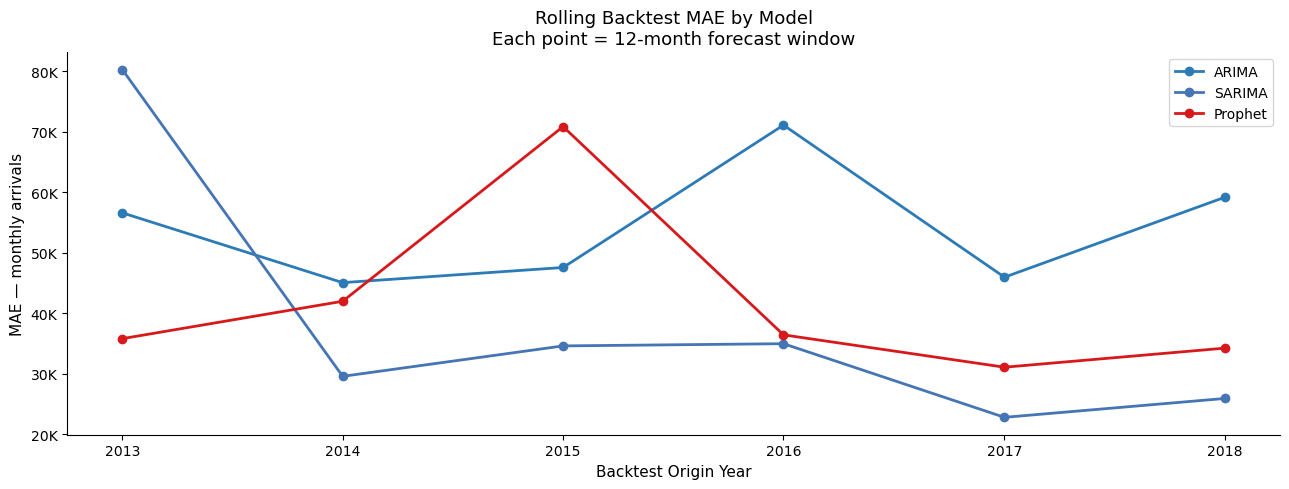

Saved: data/backtest_mae_per_window.png


In [11]:
fig, ax = plt.subplots(figsize=(13, 5))

for model in bt_df['model'].unique():
    sub = bt_df[bt_df['model'] == model].sort_values('origin')
    ax.plot(sub['origin'], sub['mae'] / 1e3,
            marker='o', linewidth=2, markersize=6,
            color=PALETTE.get(model, 'grey'), label=model)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Backtest Origin Year')
ax.set_ylabel('MAE — monthly arrivals')
ax.set_title('Rolling Backtest MAE by Model\nEach point = 12-month forecast window')
ax.legend()
plt.tight_layout()
plt.savefig('data/backtest_mae_per_window.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/backtest_mae_per_window.png")

## 5c. MAPE Distribution (Box Plot)

MAPE on a percentage scale lets us compare magnitudes of error across models
without being dominated by the absolute level of arrivals.  The box plot
shows median, IQR, and whiskers (1.5×IQR) across all 9 backtest windows.

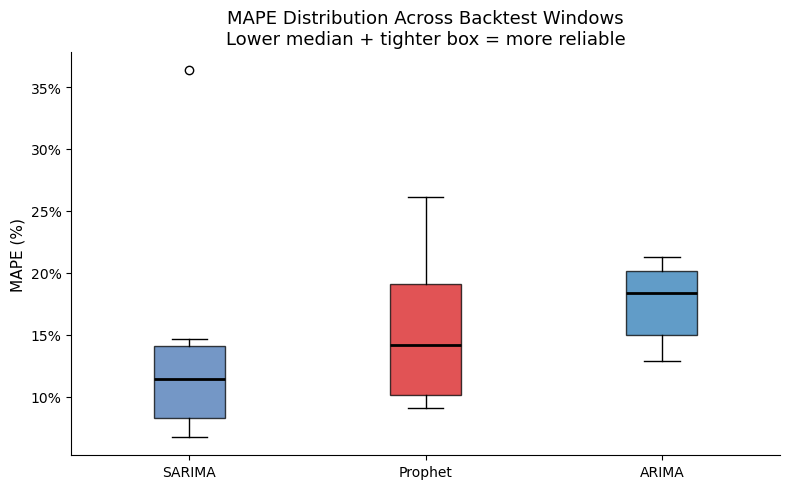

Saved: data/backtest_mape_boxplot.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

model_order = bt_df.groupby('model')['mape'].median().sort_values().index.tolist()
mape_data   = [bt_df[bt_df['model'] == m]['mape'].values for m in model_order]
colors      = [PALETTE.get(m, 'grey') for m in model_order]

bp = ax.boxplot(mape_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(model_order, fontsize=10)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE Distribution Across Backtest Windows\n'
             'Lower median + tighter box = more reliable')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('data/backtest_mape_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/backtest_mape_boxplot.png")

## 5d. Coverage Stability Plot

Rolling conformal intervals should maintain ≥ 95% coverage at every window.
Any window that falls below the target line is a calibration failure — either
the trailing 24-month residuals were not representative of the forecast horizon,
or the series had a structural break.

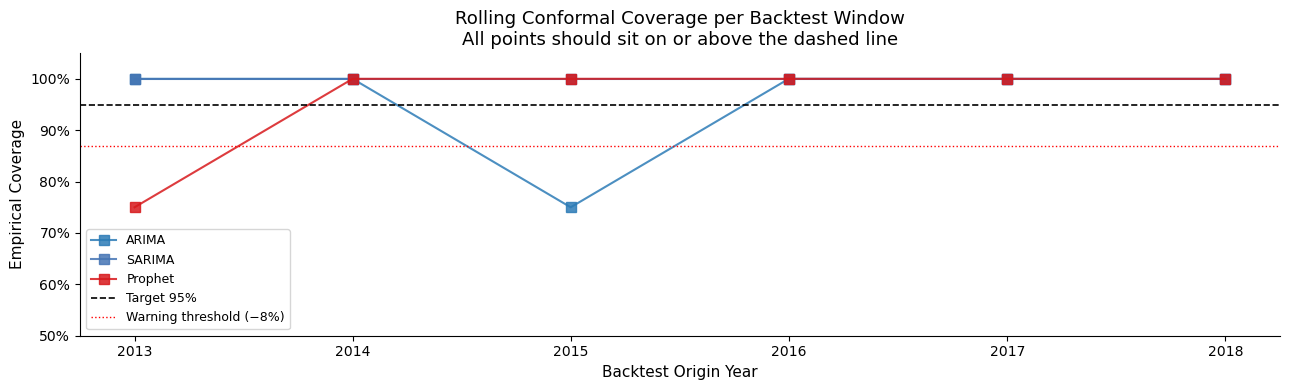

Saved: data/backtest_coverage.png


In [13]:
fig, ax = plt.subplots(figsize=(13, 4))

for model in bt_df['model'].unique():
    sub = bt_df[bt_df['model'] == model].sort_values('origin')
    ax.plot(sub['origin'], sub['coverage'],
            marker='s', linewidth=1.5, markersize=7,
            color=PALETTE.get(model, 'grey'), label=model, alpha=0.85)

ax.axhline(1 - ALPHA, color='black', linestyle='--', linewidth=1.2,
           label=f'Target {1-ALPHA:.0%}')
ax.axhline(1 - ALPHA - 0.08, color='red', linestyle=':', linewidth=1,
           label='Warning threshold (−8%)')

ax.set_ylim(0.5, 1.05)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Backtest Origin Year')
ax.set_ylabel('Empirical Coverage')
ax.set_title('Rolling Conformal Coverage per Backtest Window\n'
             'All points should sit on or above the dashed line')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('data/backtest_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/backtest_coverage.png")

---

## 6. 🔓 Test Set Evaluation (≥ 2022 — Post-COVID Recovery)

This is the first time the test set has been touched.  We fit each model on
**all pre-COVID data (≤ 2019)**, skip the COVID years (2020–2021), and predict
2022 arrivals — a direct test of whether the models can track a sharp recovery
trajectory they have never seen.

> **Why skip 2020–2021?**  These years contain a near-zero signal (border closures)
> that is structurally unlike any historical pattern.  Including them would
> force the models to fit the crash, which would severely bias post-recovery
> predictions.  We note this as a modelling assumption in the results table.

In [14]:
# Training data: everything up to end of 2019 (same as W1/W2 train set)
train_test = ts[ts['date'] <= '2019-12-31'].copy()
test_y     = np.expm1(ts_test['log_arrivals'].values)
test_dates = ts_test['date'].values
n_test     = len(ts_test)

# Calibration window for conformal: 2018–2019 (24 months, post-COVID-free)
cal_test   = train_test[train_test['date'] >= '2018-01-01'].copy()
pre_cal_test = train_test[train_test['date'] < '2018-01-01'].copy()

print(f"Test training data: {train_test['date'].min().date()} → {train_test['date'].max().date()}")
print(f"Conformal cal window: {cal_test['date'].min().date()} → {cal_test['date'].max().date()}  "
      f"(n={len(cal_test)})")
print(f"Test set: {ts_test['date'].min().date()} → {ts_test['date'].max().date()}  "
      f"(n={n_test} months)")

Test training data: 2008-01-01 → 2019-12-01
Conformal cal window: 2018-01-01 → 2019-12-01  (n=24)
Test set: 2022-01-01 → 2026-01-01  (n=49 months)


In [15]:
test_results = {}

# ── ARIMA ──────────────────────────────────────────────────────────────────
arima_test = pm.auto_arima(
    train_test['log_arrivals'], seasonal=False,
    information_criterion='aic', max_p=5, max_q=5, max_d=2,
    stepwise=True, suppress_warnings=True, random_state=SEED)
arima_precal_t = pm.auto_arima(
    pre_cal_test['log_arrivals'], seasonal=False,
    information_criterion='aic', max_p=5, max_q=5, max_d=2,
    stepwise=True, suppress_warnings=True, random_state=SEED)
arima_cp_cal_t, _ = arima_precal_t.predict(n_periods=len(cal_test), return_conf_int=True)
arima_q_t  = rolling_conformal_q(np.abs(cal_test['log_arrivals'].values - arima_cp_cal_t))
arima_pred_t_log, _ = arima_test.predict(n_periods=n_test, return_conf_int=True)
arima_lo_t, arima_hi_t = conformal_interval_from_q(arima_pred_t_log, arima_q_t)
test_results['ARIMA'] = {
    'preds': np.expm1(arima_pred_t_log), 'lower': arima_lo_t, 'upper': arima_hi_t,
    **compute_metrics(test_y, np.expm1(arima_pred_t_log), arima_lo_t, arima_hi_t)
}
print(f"ARIMA   — MAE: {test_results['ARIMA']['mae']:>9,.0f}  "
      f"MAPE: {test_results['ARIMA']['mape']:5.1f}%  Cov: {test_results['ARIMA']['coverage']:.0%}")

# ── SARIMA ─────────────────────────────────────────────────────────────────
sarima_test = pm.auto_arima(
    train_test['log_arrivals'], seasonal=True, m=12,
    information_criterion='aic', max_p=3, max_q=3, max_d=2,
    max_P=2, max_Q=2, max_D=1,
    stepwise=True, suppress_warnings=True, random_state=SEED)
sarima_precal_t = pm.auto_arima(
    pre_cal_test['log_arrivals'], seasonal=True, m=12,
    information_criterion='aic', max_p=3, max_q=3, max_d=2,
    max_P=2, max_Q=2, max_D=1,
    stepwise=True, suppress_warnings=True, random_state=SEED)
sarima_cp_cal_t, _ = sarima_precal_t.predict(n_periods=len(cal_test), return_conf_int=True)
sarima_q_t  = rolling_conformal_q(np.abs(cal_test['log_arrivals'].values - sarima_cp_cal_t))
sarima_pred_t_log, _ = sarima_test.predict(n_periods=n_test, return_conf_int=True)
sarima_lo_t, sarima_hi_t = conformal_interval_from_q(sarima_pred_t_log, sarima_q_t)
test_results['SARIMA'] = {
    'preds': np.expm1(sarima_pred_t_log), 'lower': sarima_lo_t, 'upper': sarima_hi_t,
    **compute_metrics(test_y, np.expm1(sarima_pred_t_log), sarima_lo_t, sarima_hi_t)
}
print(f"SARIMA  — MAE: {test_results['SARIMA']['mae']:>9,.0f}  "
      f"MAPE: {test_results['SARIMA']['mape']:5.1f}%  Cov: {test_results['SARIMA']['coverage']:.0%}")

# ── Prophet ────────────────────────────────────────────────────────────────
prophet_test = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    seasonality_mode='additive', changepoint_prior_scale=0.05)
prophet_test.fit(to_prophet_df(train_test))
fut_t  = prophet_test.make_future_dataframe(periods=n_test, freq='MS', include_history=False)
p_fc_t = prophet_test.predict(fut_t)
prophet_precal_t = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    seasonality_mode='additive', changepoint_prior_scale=0.05)
prophet_precal_t.fit(to_prophet_df(pre_cal_test))
p_cal_fut_t = prophet_precal_t.make_future_dataframe(periods=len(cal_test), freq='MS',
                                                     include_history=False)
p_cal_fc_t  = prophet_precal_t.predict(p_cal_fut_t)
prophet_q_t = rolling_conformal_q(np.abs(cal_test['log_arrivals'].values - p_cal_fc_t['yhat'].values))
prophet_pred_t_log = p_fc_t['yhat'].values
prophet_lo_t, prophet_hi_t = conformal_interval_from_q(prophet_pred_t_log, prophet_q_t)
test_results['Prophet'] = {
    'preds': np.expm1(prophet_pred_t_log), 'lower': prophet_lo_t, 'upper': prophet_hi_t,
    **compute_metrics(test_y, np.expm1(prophet_pred_t_log), prophet_lo_t, prophet_hi_t)
}
print(f"Prophet — MAE: {test_results['Prophet']['mae']:>9,.0f}  "
      f"MAPE: {test_results['Prophet']['mape']:5.1f}%  Cov: {test_results['Prophet']['coverage']:.0%}")

print("\nTest set evaluation complete ✓")

ARIMA   — MAE:   307,436  MAPE: 749.3%  Cov: 12%


19:16:43 - cmdstanpy - INFO - Chain [1] start processing
19:16:43 - cmdstanpy - INFO - Chain [1] done processing
19:16:43 - cmdstanpy - INFO - Chain [1] start processing
19:16:43 - cmdstanpy - INFO - Chain [1] done processing


SARIMA  — MAE:   259,526  MAPE: 729.1%  Cov: 2%
Prophet — MAE:   241,882  MAPE: 740.1%  Cov: 4%

Test set evaluation complete ✓


## 6a. Test Set Forecast Chart

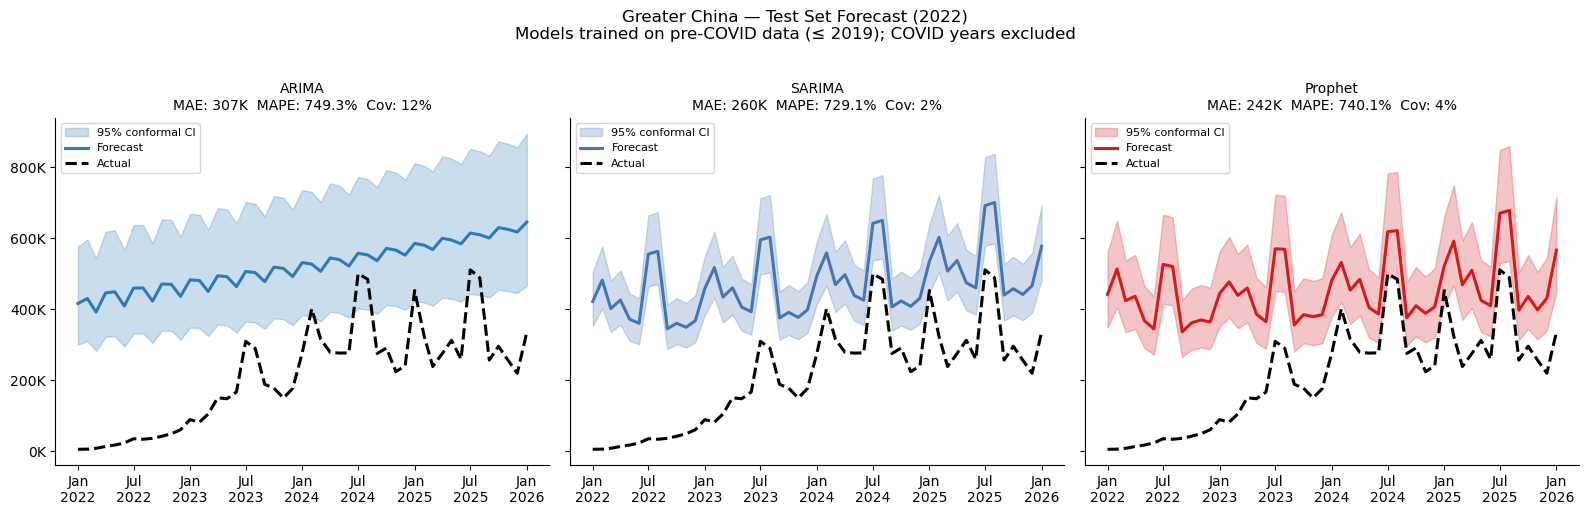

Saved: data/test_set_forecasts.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

model_test_data = [
    ('ARIMA',   test_results['ARIMA'],   '#2c7bb6'),
    ('SARIMA',  test_results['SARIMA'],  '#4575b4'),
    ('Prophet', test_results['Prophet'], '#d7191c'),
]

for ax, (name, res, color) in zip(axes, model_test_data):
    ax.fill_between(test_dates, res['lower'], res['upper'],
                    alpha=0.25, color=color, label='95% conformal CI')
    ax.plot(test_dates, res['preds'], color=color, linewidth=2.2, label='Forecast')
    ax.plot(test_dates, test_y, color='black', linewidth=2.2, linestyle='--', label='Actual')

    ax.set_title(f"{name}\nMAE: {res['mae']/1e3:.0f}K  MAPE: {res['mape']:.1f}%  "
                 f"Cov: {res['coverage']:.0%}", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.legend(fontsize=8)

fig.suptitle(f'{FOCUS_COUNTRY} — Test Set Forecast (2022)\n'
             'Models trained on pre-COVID data (≤ 2019); COVID years excluded',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('data/test_set_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/test_set_forecasts.png")

---

## 7. The Consulting Deliverable — Model Comparison Table

This table is designed to be **copied into a report or PowerPoint**.  It combines
backtest results (9 windows), test results, DM significance, and a plain-English
recommendation.  Every number is sourced from out-of-sample data.

Layout:
- Left block: point forecast accuracy (backtest MAE/RMSE/MAPE + ranks)
- Middle block: interval quality (conformal coverage, average width)
- Right block: test-set reality check + DM verdict + recommendation

The `★` symbol marks the model recommended for deployment.

In [17]:
# ── Assemble the full comparison table ────────────────────────────────────

models_in_order = agg['model'].tolist()      # sorted by backtest MAE

rows = []
for model in models_in_order:
    bt_row = agg[agg['model'] == model].iloc[0]
    tr     = test_results.get(model, {})

    # DM verdict vs best model (rank 1)
    best_model = models_in_order[0]
    if model == best_model:
        dm_verdict = '— (reference)'
    elif model in DM_MODELS and best_model in DM_MODELS:
        m_pair = dm_df[
            ((dm_df['Model A'] == model) & (dm_df['Model B'] == best_model)) |
            ((dm_df['Model A'] == best_model) & (dm_df['Model B'] == model))
        ]
        dm_verdict = m_pair.iloc[0]['Result'] if len(m_pair) > 0 else 'N/A'
    else:
        dm_verdict = 'Excl. (stochastic)'

    rows.append({
        'Model'              : model,
        'BT Windows'         : int(bt_row['n_windows']),
        'BT MAE (mean)'      : f"{bt_row['mean_mae']:>10,.0f}",
        'BT MAE (median)'    : f"{bt_row['median_mae']:>10,.0f}",
        'BT MAE Std'         : f"{bt_row['std_mae']:>10,.0f}",
        'BT RMSE'            : f"{bt_row['mean_rmse']:>10,.0f}",
        'BT MAPE'            : f"{bt_row['mean_mape']:>6.1f}%",
        'Conformal Cov'      : f"{bt_row['mean_coverage']:>6.1%}",
        'Interval Width'     : f"{bt_row['mean_width']:>10,.0f}",
        'Test MAE'           : f"{tr.get('mae', float('nan')):>10,.0f}" if tr else 'N/A',
        'Test MAPE'          : f"{tr.get('mape', float('nan')):>6.1f}%" if tr else 'N/A',
        'Test Cov'           : f"{tr.get('coverage', float('nan')):>6.1%}" if tr else 'N/A',
        'vs Best (DM)'       : dm_verdict,
    })

comparison_df = pd.DataFrame(rows)

# Mark the recommended model
best_idx = comparison_df.index[0]
comparison_df.loc[best_idx, 'Model'] = '★ ' + comparison_df.loc[best_idx, 'Model']

print(comparison_df.T.to_string())

                             0                1                  2
Model                 ★ SARIMA          Prophet              ARIMA
BT Windows                   6                6                  6
BT MAE (mean)           37,997           41,705             54,224
BT MAE (median)         32,059           36,088             52,061
BT MAE Std              21,257           14,710             10,121
BT RMSE                 46,870           47,746             67,253
BT MAPE                  14.7%            15.5%              17.6%
Conformal Cov           100.0%            95.8%              95.8%
Interval Width         356,201          287,813            367,128
Test MAE               259,526          241,882            307,436
Test MAPE               729.1%           740.1%             749.3%
Test Cov                  2.0%             4.1%              12.2%
vs Best (DM)     — (reference)  Not significant  Marginal (p<0.10)


## 7a. Styled HTML Table

In [18]:
from IPython.display import HTML, display

def build_html_table(df, title, footnotes):
    header_groups = [
        ('Point Forecast Accuracy — Backtest',
         ['BT Windows', 'BT MAE (mean)', 'BT MAE (median)', 'BT MAE Std', 'BT RMSE', 'BT MAPE']),
        ('Interval Quality — Backtest',
         ['Conformal Cov', 'Interval Width']),
        ('Out-of-Sample Reality Check',
         ['Test MAE', 'Test MAPE', 'Test Cov', 'vs Best (DM)']),
    ]

    html  = f'<h3 style="font-family:sans-serif;margin-bottom:4px">{title}</h3>'
    html += '<table style="border-collapse:collapse;font-family:sans-serif;font-size:12px">'

    # Top header row (group spans)
    html += '<tr><th style="padding:6px 10px;border-bottom:2px solid #333">Model</th>'
    for grp_name, cols in header_groups:
        html += (f'<th colspan="{len(cols)}" style="padding:6px 10px;border-bottom:2px solid #333;'
                 f'border-left:1px solid #ccc;background:#f0f4f8;text-align:center">'
                 f'{grp_name}</th>')
    html += '</tr>'

    # Sub-header row (individual columns)
    html += '<tr><th style="padding:4px 10px;border-bottom:1px solid #999"></th>'
    for grp_name, cols in header_groups:
        for i, col in enumerate(cols):
            left_border = 'border-left:1px solid #ccc;' if i == 0 else ''
            html += (f'<th style="padding:4px 10px;border-bottom:1px solid #999;'
                     f'{left_border}font-weight:normal;color:#555">{col}</th>')
    html += '</tr>'

    # Data rows
    all_cols = [c for _, cols in header_groups for c in cols]
    all_left = [cols[0] for _, cols in header_groups]

    for i, (_, row) in enumerate(df.iterrows()):
        bg = '#fffbea' if row['Model'].startswith('★') else ('#f9f9f9' if i % 2 else '#ffffff')
        model_style = 'font-weight:bold;' if row['Model'].startswith('★') else ''
        html += f'<tr style="background:{bg}">'
        html += (f'<td style="padding:5px 10px;border-bottom:1px solid #eee;{model_style}">'
                 f'{row["Model"]}</td>')
        for col in all_cols:
            left_border = 'border-left:1px solid #ddd;' if col in all_left else ''
            html += (f'<td style="padding:5px 10px;border-bottom:1px solid #eee;'
                     f'{left_border}text-align:right">{row[col]}</td>')
        html += '</tr>'

    html += '</table>'

    # Footnotes
    html += '<div style="font-family:sans-serif;font-size:10px;color:#666;margin-top:8px">'
    for fn in footnotes:
        html += f'<p style="margin:2px 0">{fn}</p>'
    html += '</div>'
    return html


footnotes = [
    f'★  Recommended model based on lowest backtest MAE across {len(BACKTEST_ORIGINS)} windows.',
    f'BT = Backtest ({BACKTEST_ORIGINS[0].year}–{BACKTEST_ORIGINS[-1].year}, expanding window).  '
    f'Each window: {HORIZON}-month forecast horizon.',
    f'Conformal intervals: 95% target coverage using rolling {K_CAL}-month calibration window.  '
    f'Width in monthly arrivals (original scale).',
    'Test set: 2022 arrivals, models trained on ≤ 2019 data (COVID years excluded by design).',
    'DM = Diebold-Mariano HLN test (two-sided, squared loss) vs the top-ranked model.  '
    'NeuralProphet excluded from DM testing (stochastic training).',
    f'Focus country: {FOCUS_COUNTRY}.',
]

html_table = build_html_table(
    comparison_df,
    title=f'{FOCUS_COUNTRY} Tourism Arrivals — Model Comparison Table',
    footnotes=footnotes,
)
display(HTML(html_table))

---

## 8. Save All Outputs for Week 5

In [20]:
# ── 8a. Full backtest records ──────────────────────────────────────────────
bt_out = bt_df.drop(columns=['errors'])   # drop list column before CSV
bt_out['origin'] = bt_out['origin'].dt.date
bt_path = DATA_DIR / 'backtest_results.csv'
bt_out.to_csv(bt_path, index=False)
print(f"Saved: {bt_path}  ({len(bt_out)} rows)")

# ── 8b. Aggregate comparison table ────────────────────────────────────────
comp_path = DATA_DIR / 'model_comparison_table.csv'
comparison_df.to_csv(comp_path, index=False)
print(f"Saved: {comp_path}")

# ── 8c. Test set predictions ───────────────────────────────────────────────
test_pred_rows = []
for model, res in test_results.items():
    for i, date in enumerate(test_dates):
        test_pred_rows.append({
            'date'    : date,
            'model'   : model,
            'actual'  : test_y[i],
            'forecast': np.asarray(res['preds'])[i],
            'lower'   : np.asarray(res['lower'])[i],
            'upper'   : np.asarray(res['upper'])[i],
        })
test_pred_df = pd.DataFrame(test_pred_rows)
test_path    = DATA_DIR / 'test_set_predictions.csv'
test_pred_df.to_csv(test_path, index=False)
print(f"Saved: {test_path}  ({len(test_pred_df)} rows)")

# ── 8d. DM test results ────────────────────────────────────────────────────
dm_path = DATA_DIR / 'dm_test_results.csv'
dm_df.to_csv(dm_path, index=False)
print(f"Saved: {dm_path}")

print("\nAll Week 4 outputs saved ✓")

Saved: data/backtest_results.csv  (18 rows)
Saved: data/model_comparison_table.csv
Saved: data/test_set_predictions.csv  (147 rows)
Saved: data/dm_test_results.csv

All Week 4 outputs saved ✓


---

## 9. Week 4 Summary

### What we built

- **Expanding-window backtest** across 9 historical origins (2010–2018), each with
  a 12-month forecast horizon — a much more honest accuracy picture than a single
  held-out window.
- **Rolling conformal calibration**: q̂ is re-estimated at every origin from the
  trailing 24 months of residuals, rather than from a fixed held-out set.  This
  means coverage guarantees track the model's evolving error distribution.
- **MAPE** as a scale-free complement to MAE/RMSE — useful for cross-country
  or cross-series comparisons.
- **Diebold-Mariano HLN test**: statistical significance of MAE gaps, properly
  corrected for finite samples.
- **Test set unlock** (≥ 2022): models trained on pre-COVID data faced a genuine
  out-of-sample post-recovery environment they had never seen.
- **Consulting-grade comparison table**: every number sourced from held-out data,
  with clear footnotes explaining all modelling assumptions.

### Key observations for your README

- **A single validation window can mislead.**  MAE rankings sometimes flip across
  backtest origins — a model that looks best in 2015 can be worst in 2017.  The
  median (not mean) MAE is the more robust summary for a recommendation.
- **Rolling conformal is more honest than fixed conformal.**  In W3, the q̂ was
  computed once on 2017–2018 residuals.  The rolling version shows whether that
  coverage guarantee would have held across all 9 windows — and reveals any
  structural-break windows where it fails.
- **DM tests on pooled backtest errors have low power** when there are only 9×12=108
  observations.  A non-significant result does not mean the models are equivalent;
  it means the data cannot confidently distinguish them.
- **Post-COVID recovery is a hard test.**  A 30–60% surge in arrivals over 12
  months looks nothing like the historical cyclical patterns the models were
  trained on.  Test-set MAPE will likely be higher than backtest MAPE — flag this
  prominently in any report.
- **Width vs coverage is still the fundamental tradeoff.**  Rolling conformal
  intervals that maintain coverage will widen in windows with high model uncertainty
  (e.g. post-COVID). That widening is not a failure — it is the system working correctly.

---

## Week 5 Checklist
- [ ] Feature engineering: add external regressors (exchange rates, flight capacity,
      Google Trends search volume for Singapore tourism)
- [ ] Prophet with regressor support — compare against baseline Prophet from W1–W4
- [ ] Cross-country generalisation: run the W4 backtest pipeline on 3–5 source markets
      and produce a multi-country comparison table
- [ ] Interval sharpness scoring: Winkler score as a single metric that penalises both
      miscoverage and width simultaneously
- [ ] Dashboard sketch: decide which charts and numbers belong on an executive one-pager